In [4]:
import tqdm as tqdm
from matplotlib import cm
from pymoc.modules import Psi_Thermwind, Psi_SO, Column
from pymoc.plotting import Interpolate_channel, Interpolate_twocol
import numpy as np
import matplotlib.pyplot as plt
from pymoc.utils import make_func
from scipy import integrate, optimize

## Load and Plot 

In [5]:
BS_NP_REF = 0.02
BS_NA_REF = 0.00036
SV_THRESH = 1
legA = np.load("Force_North_Pacific.npz")

legB = np.load("Force_North_Atlantic.npz")

xA = legA["bs_north_pac"] - BS_NP_REF
xB = legB["bs_north"] - BS_NA_REF
x = np.concatenate([xA, [np.nan],  xB[1:]])

AMOC_join = np.concatenate([legA["AMOC_strength"], [np.nan],  legB["AMOC_strength"][1:]])
PMOC_join = np.concatenate([legA["PMOC_strength"], [np.nan],legB["PMOC_strength"][1:]])
ZOC_join = np.concatenate([legA["ZOC_strength"],[np.nan], legB["ZOC_strength"][1:]])
SOA_join = np.concatenate([legA["SO_Atl_strength"], legB["SO_Atl_strength"][1:]])
SOP_join = np.concatenate([legA["SO_Pac_strength"], legB["SO_Pac_strength"][1:]])

bNA_sh = np.concatenate([legA["bNA_1Sv_shallow"], legB["bNA_1Sv_shallow"][1:]])
bNA_dp = np.concatenate([legA["bNA_1Sv_deep"],    legB["bNA_1Sv_deep"][1:]])
bSA_sh = np.concatenate([legA["bSA_1Sv_shallow"], legB["bSA_1Sv_shallow"][1:]])
bSA_dp = np.concatenate([legA["bSA_1Sv_deep"],    legB["bSA_1Sv_deep"][1:]])

bNP_sh = np.concatenate([legA["bNP_1Sv_shallow"], legB["bNP_1Sv_shallow"][1:]])
bNP_dp = np.concatenate([legA["bNP_1Sv_deep"],    legB["bNP_1Sv_deep"][1:]])
bSP_sh = np.concatenate([legA["bSP_1Sv_shallow"], legB["bSP_1Sv_shallow"][1:]])
bSP_dp = np.concatenate([legA["bSP_1Sv_deep"],    legB["bSP_1Sv_deep"][1:]])

zNA_sh = np.concatenate([legA["zNA_1Sv_shallow"], legB["zNA_1Sv_shallow"][1:]])
zNA_dp = np.concatenate([legA["zNA_1Sv_deep"],    legB["zNA_1Sv_deep"][1:]])
zSA_sh = np.concatenate([legA["zSA_1Sv_shallow"], legB["zSA_1Sv_shallow"][1:]])
zSA_dp = np.concatenate([legA["zSA_1Sv_deep"],    legB["zSA_1Sv_deep"][1:]])

zNP_sh = np.concatenate([legA["zNP_1Sv_shallow"], legB["zNP_1Sv_shallow"][1:]])
zNP_dp = np.concatenate([legA["zNP_1Sv_deep"],    legB["zNP_1Sv_deep"][1:]])
zSP_sh = np.concatenate([legA["zSP_1Sv_shallow"], legB["zSP_1Sv_shallow"][1:]])
zSP_dp = np.concatenate([legA["zSP_1Sv_deep"],    legB["zSP_1Sv_deep"][1:]])

plus = (6.0 / 21.0) * SOA_join + (15.0 / 21.0) * SOP_join

np.savez(
    "SEESAW_joined_nudged_with_bmins_two_crossings_spare.npz",
    x=np.array(x),
    AMOC_strength=np.array(AMOC_join),
    PMOC_strength=np.array(PMOC_join),
    ZOC_strength=np.array(ZOC_join),
    SO_Atl_strength=np.array(SOA_join),
    SO_Pac_strength=np.array(SOP_join),
    SO_plus_strength=np.array(plus),

    bNA_1Sv_shallow=np.array(bNA_sh),
    bNA_1Sv_deep=np.array(bNA_dp),
    bSA_1Sv_shallow=np.array(bSA_sh),
    bSA_1Sv_deep=np.array(bSA_dp),
    bNP_1Sv_shallow=np.array(bNP_sh),
    bNP_1Sv_deep=np.array(bNP_dp),
    bSP_1Sv_shallow=np.array(bSP_sh),
    bSP_1Sv_deep=np.array(bSP_dp),

    zNA_1Sv_shallow=np.array(zNA_sh),
    zNA_1Sv_deep=np.array(zNA_dp),
    zSA_1Sv_shallow=np.array(zSA_sh),
    zSA_1Sv_deep=np.array(zSA_dp),
    zNP_1Sv_shallow=np.array(zNP_sh),
    zNP_1Sv_deep=np.array(zNP_dp),
    zSP_1Sv_shallow=np.array(zSP_sh),
    zSP_1Sv_deep=np.array(zSP_dp),

    SV_THRESH=float(SV_THRESH),
    xA=np.array(xA),
    xB=np.array(xB),
    legA_years=legA["years"],
    legB_years=legB["years"],
)

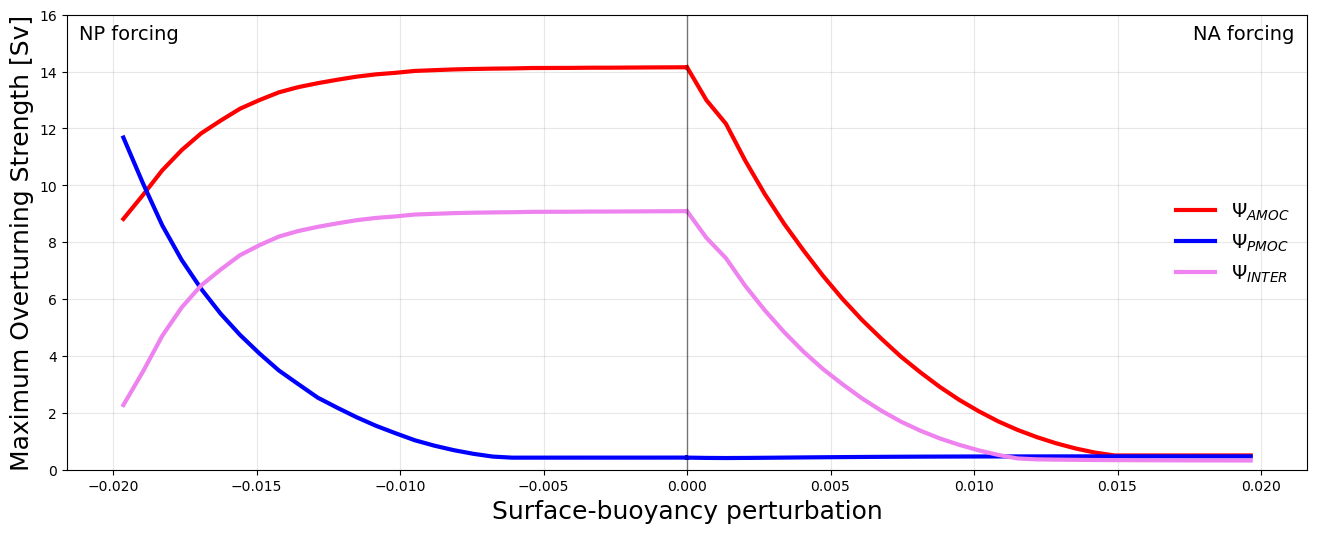

In [6]:
fig = plt.figure(figsize=(16, 13))
ax1 = fig.add_subplot(2, 1, 1)
ax1.plot(x, AMOC_join, "-", color="red", lw = 3, label=r"$\Psi_{AMOC}$")
ax1.plot(x, PMOC_join, "-", color="blue",lw = 3, label=r"$\Psi_{PMOC}$")
ax1.plot(x,ZOC_join,  "-", color="violet",lw = 3, label=r"$\Psi_{INTER}$")
# ax1.plot(x,SOA_join, ".", color = "green")
# ax1.plot(x,SOP_join, ".")

# ax1.plot(x, plus,      ".", color="slateblue", label="(6/21)SO_Atl + (15/21)SO_Pac")

ax1.axvline(0.0, color="k", lw=1, alpha=0.5)
ax1.text(0.01, 0.98, "NP forcing",
         transform=ax1.transAxes, va="top", ha="left", fontsize = "14")

ax1.text(0.99, 0.98, "NA forcing",
         transform=ax1.transAxes, va="top", ha="right", fontsize = "14")
ax1.set_xlabel("Surface-buoyancy perturbation", fontsize = "18")
ax1.set_ylabel("Maximum Overturning Strength [Sv]", fontsize = "18")
ax1.set_ylim(0,16)
ax1.set_title("")
ax1.grid(True, alpha=0.3)
ax1.legend(frameon=False, fontsize = "14")
plt.savefig("seesaw_ZOC.png")
plt.show()


## Decompose into Adiabatic and Diabatic and Plot 

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years
t= 4000 years
t= 4500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_33295/2973987984.py:355: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_33295/2973987984.py:415: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


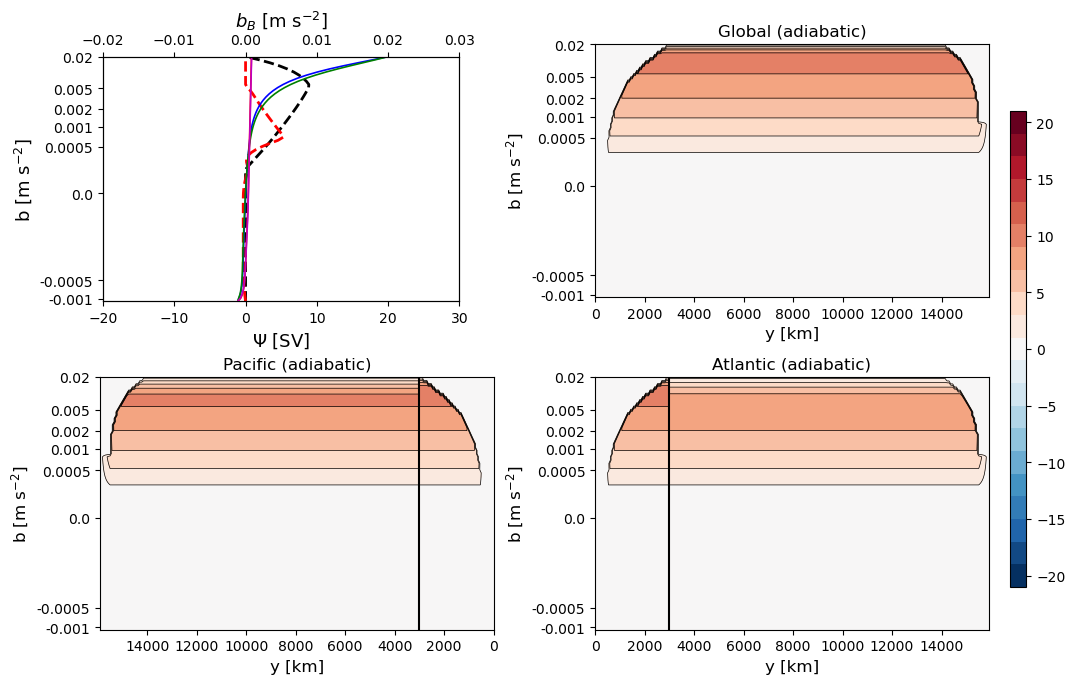

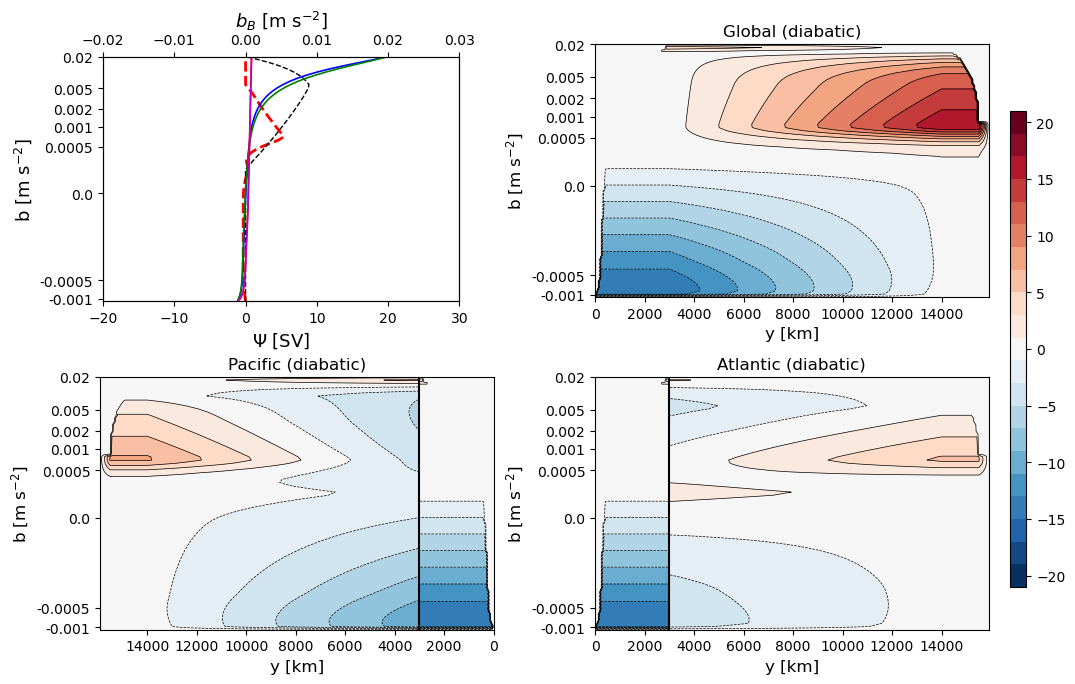

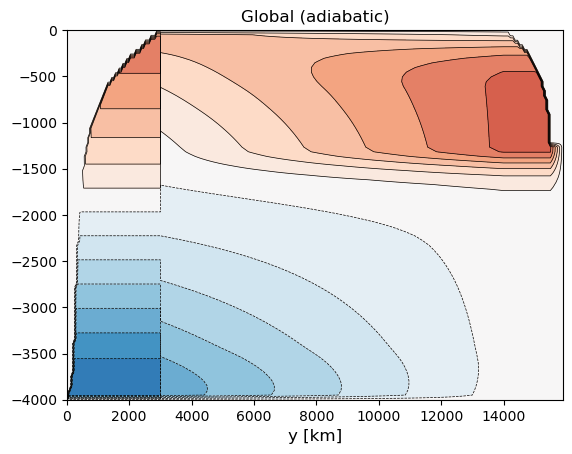

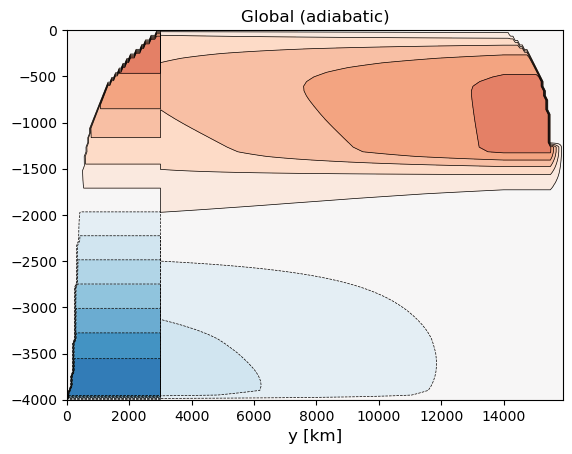

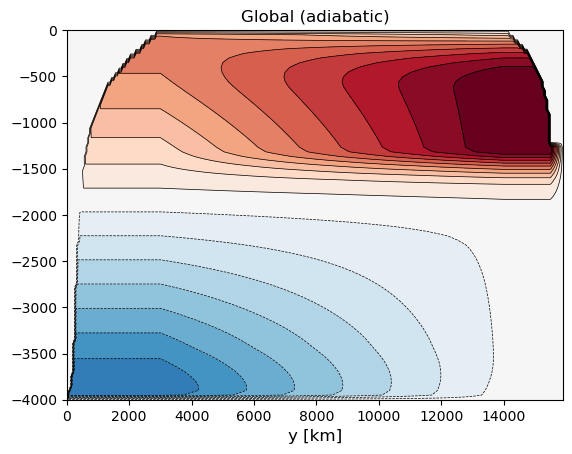

In [58]:
import numpy as np
import matplotlib.pyplot as plt


def kappaeff(z):
    return 1.0 * (
        1e-4
        * (1.1 - np.tanh(np.maximum(z + 2000.0, 0.0) / 1000.0 + np.minimum(z + 2000.0, 0.0) / 1300.0))
        * (1.0 - np.maximum(-4000.0 - z + 600.0, 0.0) / 600.0) ** 2
    )


def main():
    # bs_north_pac_vals = [0.02, 0.01, 0.005, 0.001, 0.00036]
    # bs_north_vals = np.linspace(0.00036, 0.02, 15)
    bs_north_vals = [0.00036]

    for bs_north in bs_north_vals:
        bs = 0.02
        bs_north_pac = 0.00036
        bAABW = -0.0011
        bbot = min(bAABW, bs_north, bs_north_pac)

        # Southern Ocean grid/forcing
        y = np.asarray(np.linspace(0, 3.0e6, 51))
        tau = 0.16
        offset = 0.0345 * (1 - np.cos(np.pi * (5.55e5 - 1.0e5) / 8.0e6))
        bs_SO = (
            0.0345 * (1 - np.cos(np.pi * (y - 1.0e5) / 8.0e6)) * (y > 5.55e5)
            + (bAABW - offset) / 5.55e5 * np.maximum(0, 5.55e5 - y)
            + offset * (y < 5.55e5)
        )

        # time stepping
        dt = 86400.0 * 30.0
        MOC_up_iters = int(np.floor(2.0 * 360.0 * 86400.0 / dt))
        plot_iters = int(np.ceil(500.0 * 360.0 * 86400.0 / dt))
        total_iters = int(np.ceil(5000.0 * 360.0 * 86400.0 / dt))

        # # geometry/parameters
        A_Atl = 7e13
        A_north_atl = 5.5e12
        A_Pac = 1.7e14 - 5.0e12
        A_north_pac = 5.0e12
        # geometry/parameters
        # A_Atl = 7e13
        # A_north_atl = 5.5e12
        # A_Pac = 1.7e14 - 5.5e12
        # A_north_pac = 5.5e12

        Lx = 1.3e7
        Latl = 6.0 / 21.0 * Lx
        Lpac = 15.0 / 21.0 * Lx
        K = 1800.0
        N2min = 2e-7

        z = np.asarray(np.linspace(-4000.0, 0.0, 80))

        def b_Atl(z_):
            return bs * np.exp(z_ / 300.0) + z_ / z[0] * bbot

        def b_Pac(z_):
            return bs * np.exp(z_ / 300.0) + z_ / z[0] * bbot

        # MOC components
        AMOC = Psi_Thermwind(z=z, b1=b_Atl, b2=0.01 * b_Atl(z))
        AMOC.solve()
        Psi_iso_Atl, Psi_iso_N = AMOC.Psibz()

        PMOC = Psi_Thermwind(z=z, b1=b_Pac, b2=0.01 * b_Pac(z))
        PMOC.solve()
        Psi_iso_Pac, Psi_iso_NPac = PMOC.Psibz()

        ZOC = Psi_Thermwind(z=z, b1=b_Atl, b2=b_Pac, f=1e-4)
        ZOC.solve()
        Psi_zonal_Atl, Psi_zonal_Pac = ZOC.Psibz()

        SO_Atl = Psi_SO(z=z, y=y, b=b_Atl(z), bs=bs_SO, tau=tau, L=Latl, KGM=K)
        SO_Atl.solve()

        SO_Pac = Psi_SO(z=z, y=y, b=b_Pac(z), bs=bs_SO, tau=tau, L=Lpac, KGM=K)
        SO_Pac.solve()

        # Columns
        Atl = Column(z=z, kappa=kappaeff, b=b_Atl, bs=bs, bbot=bbot, Area=A_Atl, N2min=N2min)
        north = Column(z=z, kappa=kappaeff, b=b_Atl, bs=bs_north, bbot=bbot, Area=A_north_atl, N2min=N2min)
        Pac = Column(z=z, kappa=kappaeff, b=b_Pac, bs=bs, bbot=bbot, Area=A_Pac, N2min=N2min)
        north_Pac = Column(z=z, kappa=kappaeff, b=b_Pac, bs=bs_north_pac, bbot=bbot, Area=A_north_pac, N2min=N2min)

        # spinup to equilibrium
        for ii in range(total_iters):
            wA_Atl = (Psi_iso_Atl + Psi_zonal_Atl - SO_Atl.Psi) * 1e6
            wAN = -Psi_iso_N * 1e6
            wA_Pac = (-Psi_zonal_Pac - SO_Pac.Psi + Psi_iso_Pac) * 1e6
            wA_NPac = -Psi_iso_NPac * 1e6

            Atl.timestep(wA=wA_Atl, dt=dt)
            north.timestep(wA=wAN, dt=dt, do_conv=True)
            Pac.timestep(wA=wA_Pac, dt=dt)
            north_Pac.timestep(wA=wA_NPac, dt=dt, do_conv=True)

            if ii % MOC_up_iters == 0:
                AMOC.update(b1=Atl.b, b2=north.b)
                AMOC.solve()
                Psi_iso_Atl, Psi_iso_N = AMOC.Psibz()

                PMOC.update(b1=Pac.b, b2=north_Pac.b)
                PMOC.solve()
                Psi_iso_Pac, Psi_iso_NPac = PMOC.Psibz()

                ZOC.update(b1=Atl.b, b2=Pac.b)
                ZOC.solve()
                Psi_zonal_Atl, Psi_zonal_Pac = ZOC.Psibz()

                SO_Atl.update(b=Atl.b)
                SO_Atl.solve()
                SO_Pac.update(b=Pac.b)
                SO_Pac.solve()

            if ii % plot_iters == 0:
                print("t=", round(ii * dt / 86400.0 / 360.0), "years")



        plevs = np.arange(-21.0, 23.0, 2.0)
        nb = 500

        # basin-mean buoyancy profiles used as the "b coordinate" (indexed by z)
        b_basin = (A_Atl * Atl.b + A_Pac * Pac.b) / (A_Atl + A_Pac)
        b_north_mix = (A_north_atl * north.b + A_north_pac * north_Pac.b) / (A_north_atl + A_north_pac)

        # total SO residual in buoyancy space at constant b

        PsiSO_A = np.interp(b_basin, Atl.b, SO_Atl.Psi)
        PsiSO_P = np.interp(b_basin, Pac.b, SO_Pac.Psi)

        PsiSO = PsiSO_A + PsiSO_P
        # PsiSO = np.interp(b_basin, Atl.b, SO_Atl.Psi) + np.interp(b_basin, Pac.b, SO_Pac.Psi)  #old (10/6)

        # AMOC/PMOC mapped to basin b
        AMOC_bbasin = np.interp(b_basin, AMOC.bgrid, AMOC.Psib(nb=nb))
        PMOC_bbasin = np.interp(b_basin, PMOC.bgrid, PMOC.Psib(nb=nb))

        # #compute with individual SO sectors
        PsiSO_bgrid_A = (
            np.interp(AMOC.bgrid, Atl.b, SO_Atl.Psi) + np.interp(AMOC.bgrid, Pac.b, SO_Pac.Psi)
        )
        PsiSO_bgrid_P = (
            np.interp(PMOC.bgrid, Atl.b, SO_Atl.Psi) + np.interp(PMOC.bgrid, Pac.b, SO_Pac.Psi)
        )
        # PsiSO_bgrid_A = np.interp(
        #     AMOC.bgrid,
        #     Atl.b,
        #     SO_Atl.Psi
        # )
        
        # PsiSO_bgrid_P = np.interp(
        #     PMOC.bgrid,
        #     Pac.b,
        #     SO_Pac.Psi
        # )
        # basin-specific adiabatic limiters on their own grids
        C3 = AMOC.Psib(nb=nb)
        Cadia_A = np.minimum(np.maximum(C3, 0.0), np.maximum(PsiSO_bgrid_A, 0.0))
        Cadia_bbasin_A = np.interp(b_basin, AMOC.bgrid, Cadia_A)

        C6 = PMOC.Psib(nb=nb)
        Cadia_P = np.minimum(np.maximum(C6, 0.0), np.maximum(PsiSO_bgrid_P, 0.0))
        Cadia_bbasin_P = np.interp(b_basin, PMOC.bgrid, Cadia_P)

        Cadia_global = np.minimum(
            np.maximum(AMOC_bbasin + PMOC_bbasin, 0),
            np.maximum(PsiSO, 0)
        )        
        # For the SO channel, use the SO-limited adiabatic partitions (consistent)
        Cadia_SO_bbasin_A = Cadia_bbasin_A.copy()
        Cadia_SO_bbasin_P = Cadia_bbasin_P.copy()

        l = y[-1]
        bs_tmp = 1.0 * bs_SO
        bn_tmp = 1.0 * b_basin
        bs_tmp[-1] = 1.0 * bn_tmp[-1]

        bint = Interpolate_channel(y=y, z=z, bs=bs_tmp, bn=bn_tmp)
        bsouth = bint.gridit()

        lbasin = 11000.0
        ltrans = 1500.0
        lnorth = 400.0
        lchannel = l / 1e3

        ybasin = np.linspace(0, lbasin, 60) + lchannel
        bbasin = np.tile(b_basin, (len(ybasin), 1))

        ytrans = np.linspace(ltrans / 20.0, ltrans, 20) + lchannel + lbasin
        bn = b_north_mix.copy()
        bn[0] = b_basin[0]
        bint = Interpolate_twocol(y=ytrans * 1000.0 - ytrans[0] * 1000.0, z=z, bs=Atl.b, bn=bn)
        btrans = bint.gridit()

        ynorth = np.linspace(lnorth / 20.0, lnorth, 20) + lchannel + lbasin + ltrans
        bnorth = np.tile(bn, (len(ynorth), 1))

        ynew = np.concatenate((y / 1e3, ybasin, ytrans, ynorth))
        bnew = np.concatenate((bsouth, bbasin, btrans, bnorth))


        psi_tot = np.zeros((len(ynew), len(z)))
        psi_tot_A = np.zeros((len(ynew), len(z)))
        psi_tot_P = np.zeros((len(ynew), len(z)))

        psi_adia = np.zeros((len(ynew), len(z)))
        psi_adia_A = np.zeros((len(ynew), len(z)))
        psi_adia_P = np.zeros((len(ynew), len(z)))


        # In buoyancy coordinates, only isopycnals that do NOT outcrop carry transport.
        for iy in range(1, len(y)):
            mask = (b_basin < bs_SO[iy])  

            # total (same SO residual on constant-b)
            psi_tot[iy, mask] = PsiSO[mask]
            # # if you want basin partitions in SO: keep them identical to total 
            psi_tot_A[iy, mask] = PsiSO[mask]
            psi_tot_P[iy, mask] = PsiSO[mask]
            # psi_tot_A[iy, mask] = PsiSO_A[mask]  #new
            # psi_tot_P[iy, mask] = PsiSO_P[mask]
            # SO_Atl_b = np.interp(b_basin, Atl.b, SO_Atl.Psi)
            # SO_Pac_b = np.interp(b_basin, Pac.b, SO_Pac.Psi)
            
            # psi_tot_A[iy,mask] = SO_Atl_b[mask]
            # psi_tot_P[iy,mask] = SO_Pac_b[mask]

            # adiabatic partitions (explicit, no residual definition)
            psi_adia_A[iy, mask] = Cadia_SO_bbasin_A[mask]
            psi_adia_P[iy, mask] = Cadia_SO_bbasin_P[mask]    
            psi_adia[iy, mask] = psi_adia_A[iy, mask] + psi_adia_P[iy, mask]
            psi_adia[iy, mask] = Cadia_global[mask]
            psi_adia_A[iy, mask] = psi_adia[iy, mask]
            psi_adia_P[iy, mask] = psi_adia[iy, mask]

        for iy in range(len(y), len(y) + len(ybasin)):
            wMOC = (ynew[iy] - lchannel) / lbasin
            wSO = (lchannel + lbasin - ynew[iy]) / lbasin

            psi_tot[iy, :] = wMOC * (AMOC_bbasin + PMOC_bbasin) + wSO * PsiSO

            # basin-resolved totals 
            psi_tot_A[iy, :] = (
                wMOC * AMOC_bbasin
                + wSO * (np.interp(b_basin, Atl.b, SO_Atl.Psi) - np.interp(b_basin, ZOC.bgrid, ZOC.Psib()))
            )
            psi_tot_P[iy, :] = (
                wMOC * PMOC_bbasin
                + wSO * (np.interp(b_basin, Pac.b, SO_Pac.Psi) + np.interp(b_basin, ZOC.bgrid, ZOC.Psib()))
            )

            psi_adia_A[iy, :] = wMOC * Cadia_bbasin_A + wSO * Cadia_SO_bbasin_A
            psi_adia_P[iy, :] = wMOC * Cadia_bbasin_P + wSO * Cadia_SO_bbasin_P
            # psi_adia[iy, :] = psi_adia_A[iy, :] + psi_adia_P[iy, :]
            psi_adia[iy, mask] = Cadia_global[mask]

        for iy in range(len(y) + len(ybasin), len(y) + len(ybasin) + len(ytrans)):
            # only non-outcropped isopycnals (below local surface buoyancy) carry transport
            mask = (b_basin < bnew[iy, -1])

            psi_tot[iy, mask] = AMOC_bbasin[mask] + PMOC_bbasin[mask]
            psi_tot_A[iy, mask] = AMOC_bbasin[mask]
            psi_tot_P[iy, mask] = PMOC_bbasin[mask]

            psi_adia_A[iy, mask] = Cadia_bbasin_A[mask]
            psi_adia_P[iy, mask] = Cadia_bbasin_P[mask]
            psi_adia[iy, mask] = psi_adia_A[iy, mask] + psi_adia_P[iy, mask]
            psi_adia[iy,mask] = Cadia_global[mask]

        for iy in range(len(y) + len(ybasin) + len(ytrans), len(ynew)):
            factor = max(0.0, (lchannel + lbasin + ltrans + lnorth - ynew[iy]) / lnorth)
            mask = (b_basin < bnew[iy, -1])

            psi_tot[iy, mask] = factor * (AMOC_bbasin[mask] + PMOC_bbasin[mask])
            psi_tot_A[iy, mask] = factor * AMOC_bbasin[mask]
            psi_tot_P[iy, mask] = factor * PMOC_bbasin[mask]

            psi_adia_A[iy, mask] = factor * Cadia_bbasin_A[mask]
            psi_adia_P[iy, mask] = factor * Cadia_bbasin_P[mask]
            psi_adia[iy, mask] = psi_adia_A[iy, mask] + psi_adia_P[iy, mask]
            psi_adia[iy, mask] = factor*Cadia_global[mask]

        psi_dia = psi_tot - psi_adia
        psi_dia_A = psi_tot_A - psi_adia_A
        psi_dia_P = psi_tot_P - psi_adia_P

        yticks_vals = [0.02, 0.005, 0.002, 0.001, 0.0005, 0.0, -0.0005, -0.001]
        yticks_pos = np.interp(yticks_vals, b_basin, z)

        def format_b_axis(ax):
            ax.set_yticks(yticks_pos)
            ax.set_yticklabels(yticks_vals)
            ax.set_ylabel("b [m s$^{-2}$]", fontsize=12)

        fig = plt.figure(figsize=(10.8, 6.8))

        # diagnostic panel
        ax1 = fig.add_axes([0.1, 0.57, 0.33, 0.36])
        ax2 = ax1.twiny()
        ax1.set_ylim((-4000.0, 0.0))
        ax1.set_xlim((-20, 30))
        ax2.set_xlim((-0.02, 0.030))
        ax1.set_xlabel("$\\Psi$ [SV]", fontsize=13)
        ax1.set_ylabel("b [m s$^{-2}$]", fontsize=13)
        ax2.set_xlabel("$b_B$ [m s$^{-2}$]", fontsize=13)

        ax1.plot(np.interp(b_basin, AMOC.bgrid, Cadia_A), z, "--k", linewidth=2.0)
        ax1.plot(np.interp(b_basin, AMOC.bgrid, C3 - Cadia_A), z, "--r", linewidth=2.0)
        ax2.plot(Atl.b, Atl.z, "-b", linewidth=1.2)
        ax2.plot(Pac.b, Pac.z, "-g", linewidth=1.2)
        ax2.plot(north.b, north.z, "-r", linewidth=1.2)
        ax2.plot(north_Pac.b, north_Pac.z, "-m", linewidth=1.2)
        ax1.plot(0.0 * b_basin, b_basin, linewidth=0.5, color="k", linestyle=":")

        ax1.set_yticks(yticks_pos)
        ax1.set_yticklabels(yticks_vals)

        # Global adiabatic
        ax = fig.add_subplot(222)
        ax.contour(ynew, z, psi_adia.T, levels=plevs, colors="k", linewidths=0.5)
        CS = ax.contourf(ynew, z, psi_adia.T, levels=plevs, cmap=plt.cm.RdBu_r, vmin=-20, vmax=20)
        ax.set_xlim([0, ynew[-1]])
        ax.set_xlabel("y [km]", fontsize=12)
        format_b_axis(ax)
        ax.set_title("Global (adiabatic)", fontsize=12)

        # Pacific adiabatic
        ax = fig.add_subplot(223)
        ax.contour(ynew, z, psi_adia_P.T, levels=plevs, colors="k", linewidths=0.5)
        ax.contourf(ynew, z, psi_adia_P.T, levels=plevs, cmap=plt.cm.RdBu_r, vmin=-20, vmax=20)
        ax.plot(np.array([y[-1] / 1000.0, y[-1] / 1000.0]), np.array([-4000.0, 0.0]), color="k")
        ax.set_xlim([0, ynew[-1]])
        ax.set_xlabel("y [km]", fontsize=12)
        format_b_axis(ax)
        ax.set_title("Pacific (adiabatic)", fontsize=12)
        plt.gca().invert_xaxis()

        # Atlantic adiabatic
        ax = fig.add_subplot(224)
        ax.contour(ynew, z, psi_adia_A.T, levels=plevs, colors="k", linewidths=0.5)
        ax.contourf(ynew, z, psi_adia_A.T, levels=plevs, cmap=plt.cm.RdBu_r, vmin=-20, vmax=20)
        ax.plot(np.array([y[-1] / 1000.0, y[-1] / 1000.0]), np.array([-4000.0, 0.0]), color="k")
        ax.set_xlim([0, ynew[-1]])
        ax.set_xlabel("y [km]", fontsize=12)
        format_b_axis(ax)
        ax.set_title("Atlantic (adiabatic)", fontsize=12)

        cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])
        fig.tight_layout()
        fig.subplots_adjust(right=0.92)
        fig.colorbar(CS, cax=cbar_ax, ticks=np.arange(-20, 21, 5), orientation="vertical")
        plt.savefig(f"Isopycnal_Adiabatic_bs_NA_forcing{bs_north:.6f}.png", dpi=200)


        fig = plt.figure(figsize=(10.8, 6.8))

        # diagnostic panel
        ax1 = fig.add_axes([0.1, 0.57, 0.33, 0.36])
        ax2 = ax1.twiny()
        ax1.set_ylim((-4000.0, 0.0))
        ax1.set_xlim((-20, 30))
        ax2.set_xlim((-0.02, 0.030))
        ax1.set_xlabel("$\\Psi$ [SV]", fontsize=13)
        ax1.set_ylabel("b [m s$^{-2}$]", fontsize=13)
        ax2.set_xlabel("$b_B$ [m s$^{-2}$]", fontsize=13)

        ax1.plot(np.interp(b_basin, AMOC.bgrid, C3 - Cadia_A), z, "--r", linewidth=2.0)
        ax1.plot(np.interp(b_basin, AMOC.bgrid, Cadia_A), z, "--k", linewidth=1.0)
        ax2.plot(Atl.b, Atl.z, "-b", linewidth=1.2)
        ax2.plot(Pac.b, Pac.z, "-g", linewidth=1.2)
        ax2.plot(north.b, north.z, "-r", linewidth=1.2)
        ax2.plot(north_Pac.b, north_Pac.z, "-m", linewidth=1.2)
        ax1.plot(0.0 * b_basin, b_basin, linewidth=0.5, color="k", linestyle=":")

        ax1.set_yticks(yticks_pos)
        ax1.set_yticklabels(yticks_vals)

        # Global diabatic
        ax = fig.add_subplot(222)
        ax.contour(ynew, z, psi_dia.T, levels=plevs, colors="k", linewidths=0.5)
        CS = ax.contourf(ynew, z, psi_dia.T, levels=plevs, cmap=plt.cm.RdBu_r, vmin=-20, vmax=20)
        ax.set_xlim([0, ynew[-1]])
        ax.set_xlabel("y [km]", fontsize=12)
        format_b_axis(ax)
        ax.set_title("Global (diabatic)", fontsize=12)

        # Pacific diabatic
        ax = fig.add_subplot(223)
        ax.contour(ynew, z, psi_dia_P.T, levels=plevs, colors="k", linewidths=0.5)
        ax.contourf(ynew, z, psi_dia_P.T, levels=plevs, cmap=plt.cm.RdBu_r, vmin=-20, vmax=20)
        ax.plot(np.array([y[-1] / 1000.0, y[-1] / 1000.0]), np.array([-4000.0, 0.0]), color="k")
        ax.set_xlim([0, ynew[-1]])
        ax.set_xlabel("y [km]", fontsize=12)
        format_b_axis(ax)
        ax.set_title("Pacific (diabatic)", fontsize=12)
        plt.gca().invert_xaxis()

        # Atlantic diabatic
        ax = fig.add_subplot(224)
        ax.contour(ynew, z, psi_dia_A.T, levels=plevs, colors="k", linewidths=0.5)
        ax.contourf(ynew, z, psi_dia_A.T, levels=plevs, cmap=plt.cm.RdBu_r, vmin=-20, vmax=20)
        ax.plot(np.array([y[-1] / 1000.0, y[-1] / 1000.0]), np.array([-4000.0, 0.0]), color="k")
        ax.set_xlim([0, ynew[-1]])
        ax.set_xlabel("y [km]", fontsize=12)
        format_b_axis(ax)
        ax.set_title("Atlantic (diabatic)", fontsize=12)

        cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])
        fig.tight_layout()
        fig.subplots_adjust(right=0.92)
        fig.colorbar(CS, cax=cbar_ax, ticks=np.arange(-20, 21, 5), orientation="vertical")
        
        
        # plt.savefig(f"Isopycnal_Diabatic_bs_NA_forcing{bs_north:.6f}.png", dpi=200)

        plt.show()


            
        total =  psi_adia_P + psi_dia_P
        plt.contour(ynew, z, total.T, levels=plevs, colors="k", linewidths=0.5)
        plt.contourf(ynew, z, total.T, levels=plevs, cmap=plt.cm.RdBu_r, vmin=-20, vmax=20)
        plt.xlim([0, ynew[-1]])
        plt.xlabel("y [km]", fontsize=12)
        plt.title("Global (adiabatic)", fontsize=12)
        plt.show()

        total =  psi_adia_A + psi_dia_A
        plt.contour(ynew, z, total.T, levels=plevs, colors="k", linewidths=0.5)
        plt.contourf(ynew, z, total.T, levels=plevs, cmap=plt.cm.RdBu_r, vmin=-20, vmax=20)
        plt.xlim([0, ynew[-1]])
        plt.xlabel("y [km]", fontsize=12)
        plt.title("Global (adiabatic)", fontsize=12)
        plt.show()

        total =  psi_adia + psi_dia
        plt.contour(ynew, z, total.T, levels=plevs, colors="k", linewidths=0.5)
        plt.contourf(ynew, z, total.T, levels=plevs, cmap=plt.cm.RdBu_r, vmin=-20, vmax=20)
        plt.xlim([0, ynew[-1]])
        plt.xlabel("y [km]", fontsize=12)
        plt.title("Global (adiabatic)", fontsize=12)
        plt.show()
if __name__ == "__main__":
    main()
